<a href="https://colab.research.google.com/github/bavucadoz/PCVK-Ganjil-2026/blob/main/Week3_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Arya Bayu Samodra'
NIM = '244107020162'

N = int(NIM[-3:])
PARAM = {
  'b' : (N % 61) + 20,
  'a' : round(1.0 + (N % 9) / 10, 1),
  'c' : (N % 20) + 30,
  'gamma': round(0.4 + (N % 6) * 0.25, 2),
  'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

# **PRAKTIKUM**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import glob, os
from math import log10, sqrt

BASE = '/content/drive/MyDrive/PCVK/Images/'

In [128]:
# fungsi memperkecil resolusi foto agar ukuran .ipynb tetap kecil
def resize_image(img, max_width=800):
    if img is None:
        return None
    h, w = img.shape[:2]
    if w > max_width:
        ratio = max_width / float(w)
        new_dim = (max_width, int(h * ratio))
        return cv.resize(img, new_dim, interpolation=cv.INTER_AREA)
    return img

 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan nilai kecerahan: 30


/tmp/ipykernel_1323/577053768.py:17: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


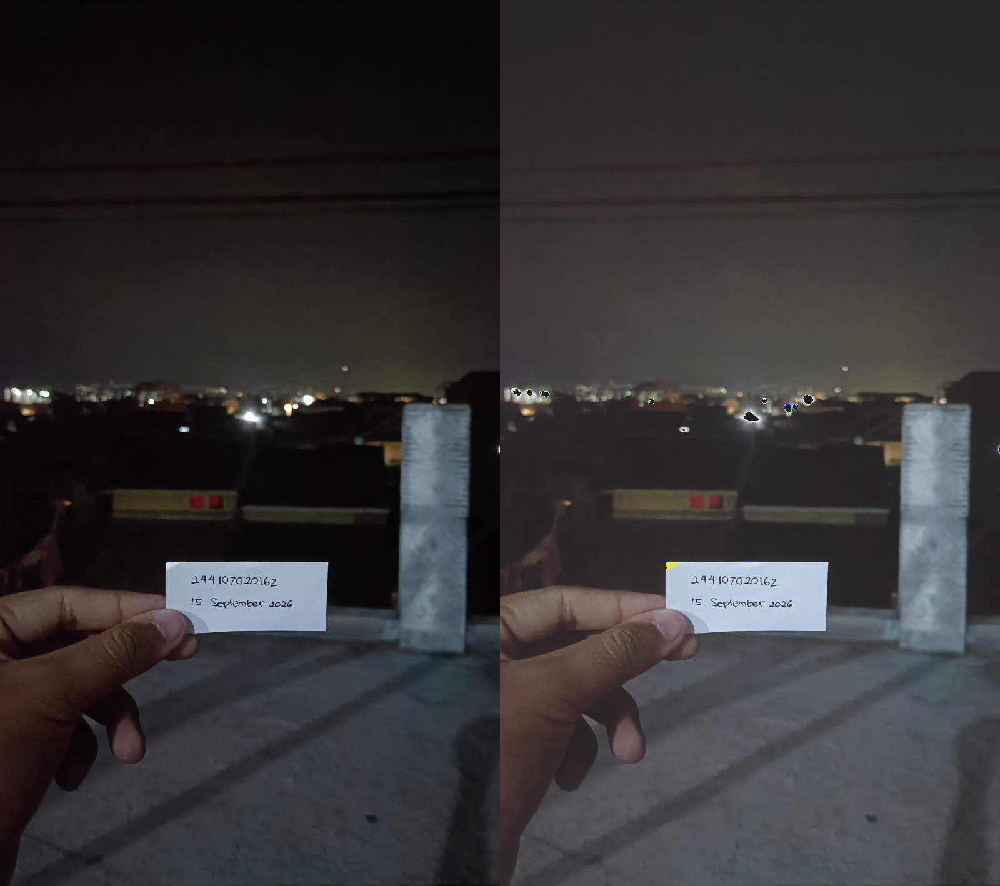

In [129]:
print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = resize_image(cv.imread('/content/drive/MyDrive/PCVK/Images/NIGHT1.jpg'))
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

# **TUGAS PRAKTIKUM**

In [ ]:
# ===== SEL IDENTITAS =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Arya Bayu Samodra'
NIM = '244107020162'

N = int(NIM[-3:])
PARAM = {
  'b' : (N % 61) + 20,
  'a' : round(1.0 + (N % 9) / 10, 1),
  'c' : (N % 20) + 30,
  'gamma': round(0.4 + (N % 6) * 0.25, 2),
  'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

**Tugas 1 - Inverse Citra**

Inverse Citra
-----------------------------------
244107020162 - Inverse KTM1a.jpg


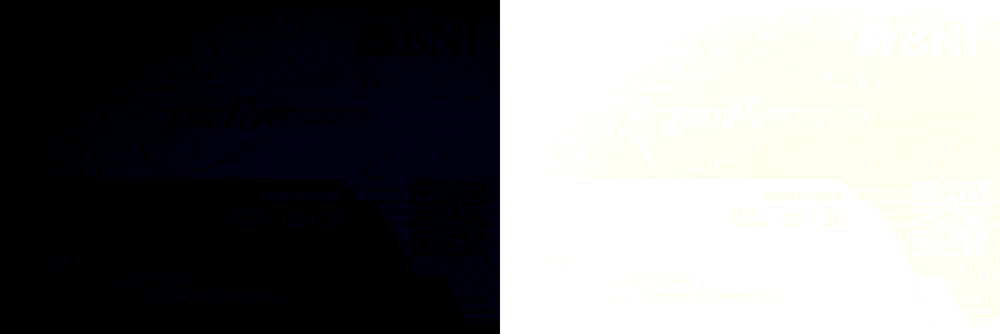

In [130]:
print('Inverse Citra')
print('-----------------------------------')


original = resize_image(cv.imread(BASE + '/KTM1a.jpg'))
inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))
print(NIM, '- Inverse KTM1a.jpg')
cv2_imshow(final_frame)

244107020162 - Inverse KTM1b.jpg


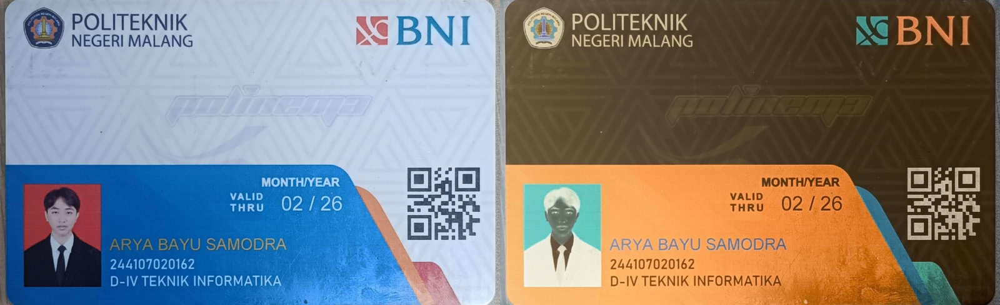

In [131]:
original = resize_image(cv.imread(BASE + '/KTM1b.jpg'))
inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))
print(NIM, '- Inverse KTM1b.jpg')
cv2_imshow(final_frame)

KTM1a memiliki sebagian besar piksel bernilai mendekati 0. Saat di-inverse, nilai intensitas pikselnya berubah menjadi mendekati 255. Hal ini menyebabkan latar belakang dan mayoritas area menjadi sangat putih mendominasi, sehingga citra terlihat pucat dan berkabut.

Sedangkan, KTM1b memiliki sebaran nilai piksel gelap dan terangnya yang lebih seimbang dan memilik rentang kontras normal. Saat di-inverse, distribusi kontras tetap terjaga dengan baik sehingga citra negatifnya tetap terlihat jelas dan kontras.

**Tugas 2 - Transformasi Kontras**

Mengubah kontras citra
-----------------------------------
244107020162 - contrast a = 1.0


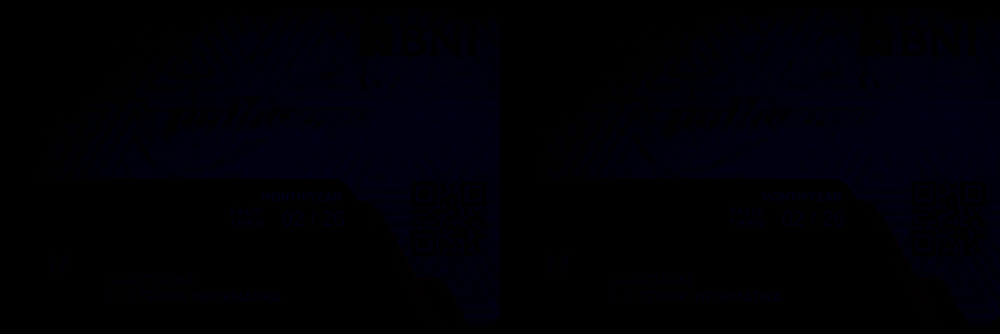

In [132]:
print('Mengubah kontras citra')
print('-----------------------------------')

a = PARAM['a']
original = resize_image(cv.imread(BASE + '/KTM1a.jpg'))

contrast_image = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            contrast_image[y, x, c] = np.clip(a * original[y, x, c], 0, 255)

final_frame = cv.hconcat((original, contrast_image))
print(NIM, '- contrast a =', a)
cv2_imshow(final_frame)

**Tugas 3 - Logarithmic Brightness vs Linear Brightness**

Mengubah tingkat kecerahan citra dengan Transformasi Log
-----------------------------------------------------
244107020162 - log c = 32
nilai kecerahan: 32


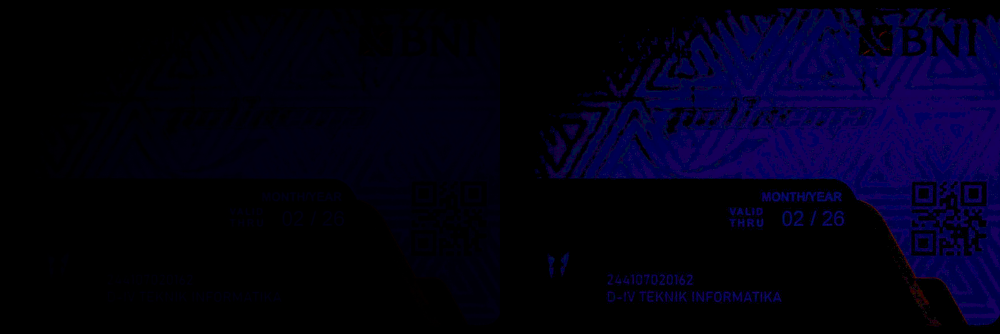

In [133]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('-----------------------------------------------------')

c = PARAM['c']
original = resize_image(cv.imread(BASE + '/KTM1a.jpg'))

log_image = c * np.log1p(original.astype(np.float64))
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((original, log_image))
print(NIM, '- log c =', c)
print('nilai kecerahan:', c)
cv2_imshow(final_frame)


Mengubah tingkat kecerahan citra (Linear)
-----------------------------------------------------
244107020162 - linear b = 60


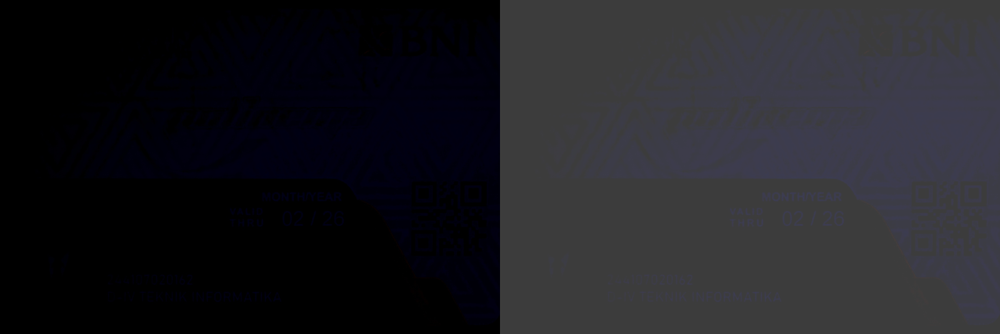

In [134]:
print('Mengubah tingkat kecerahan citra (Linear)')
print('-----------------------------------------------------')

b = PARAM['b']
linear_image = np.clip(original.astype(np.int16) + b, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((original, linear_image))
print(NIM, '- linear b =', b)

cv2_imshow(final_frame)

In [135]:
lin_clip = (linear_image == 255).mean() * 100
log_clip = (log_image == 255).mean() * 100

print('=== HASIL ANALISIS', NIM ,'===')

print(f"Piksel Maksimum Linear Brightness: {linear_image.max()} (Clipping 255: {lin_clip:.2f}%)")
print(f"Piksel Maksimum Log Brightness   : {log_image.max()} (Clipping 255: {log_clip:.2f}%)")

=== HASIL ANALISIS 244107020162 ===
Piksel Maksimum Linear Brightness: 87 (Clipping 255: 0.00%)
Piksel Maksimum Log Brightness   : 106 (Clipping 255: 0.00%)


Transformasi Logarithmic Brightness membuat teks NIM lebih mudah dibaca dibandingkan Linear Brightness. Logaritma meregangkan nilai kontras pada area gelap secara non-linier sehingga detail di area gelap terangkat tajam tanpa harus menaikkan seluruh kecerahan gambar secara merata.

**Tugas 4 - Grayscale: Averaging, Lightness, Luminance**

a. Averaging


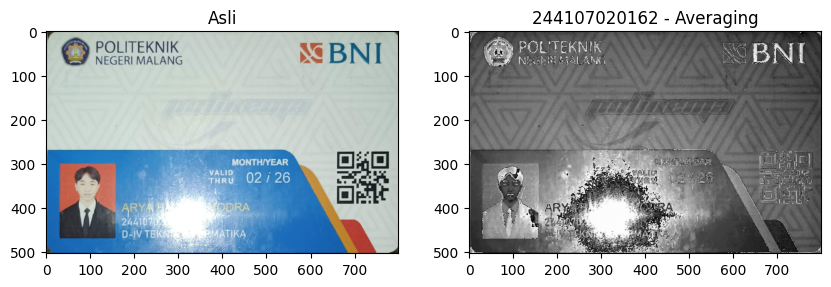

b. Lightness


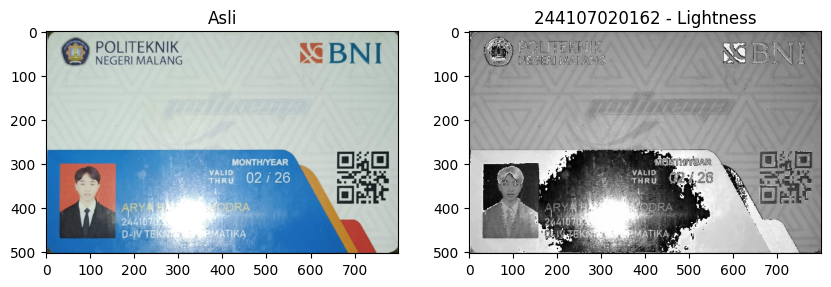

c. Luminance


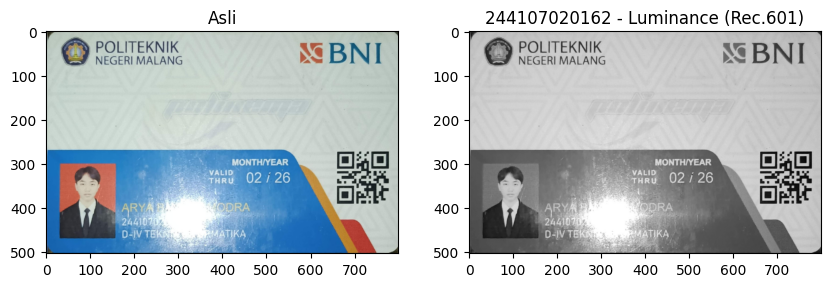

Metode            Rata-rata     Std Dev
Averaging             36.79       16.24
Lightness             72.87       28.70
Luminance            173.20       49.75


In [136]:
original = resize_image(cv.imread(BASE + '/KTM1c.jpg'))
b, g, r = cv.split(original)

gray_avg   = ((r + g + b) / 3.0)

stacked = np.stack([r, g, b], axis=-1)
gray_light = ((stacked.max(axis=-1) + stacked.min(axis=-1)) / 2.0)

gray_lum   = (0.299 * r + 0.587 * g + 0.114 * b)   # Rec. 601

plt.figure(figsize=(10, 5))
print('a. Averaging')
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); plt.title('Asli')
plt.subplot(1, 2, 2); plt.imshow(gray_avg, cmap='gray'); plt.title(NIM + ' - Averaging')
plt.show()

plt.figure(figsize=(10, 5))
print('b. Lightness')
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); plt.title('Asli')
plt.subplot(1, 2, 2); plt.imshow(gray_light, cmap='gray'); plt.title(NIM + ' - Lightness')
plt.show()

plt.figure(figsize=(10, 5))
print('c. Luminance')
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); plt.title('Asli')
plt.subplot(1, 2, 2); plt.imshow(gray_lum, cmap='gray'); plt.title(NIM + ' - Luminance (Rec.601)')
plt.show()

print(f"{'Metode':<15}{'Rata-rata':>12}{'Std Dev':>12}")
print(f"{'Averaging':<15}{gray_avg.mean():>12.2f}{gray_avg.std():>12.2f}")
print(f"{'Lightness':<15}{gray_light.mean():>12.2f}{gray_light.std():>12.2f}")
print(f"{'Luminance':<15}{gray_lum.mean():>12.2f}{gray_lum.std():>12.2f}")


Metode Luminance memberi pemisahan paling jelas antara teks, gambar dan latar kartu. Hal ini bisa kita lihat dari output programnya diatas.

**Tugas 5 - Highlight Satu Warna, Sisanya Grayscale**

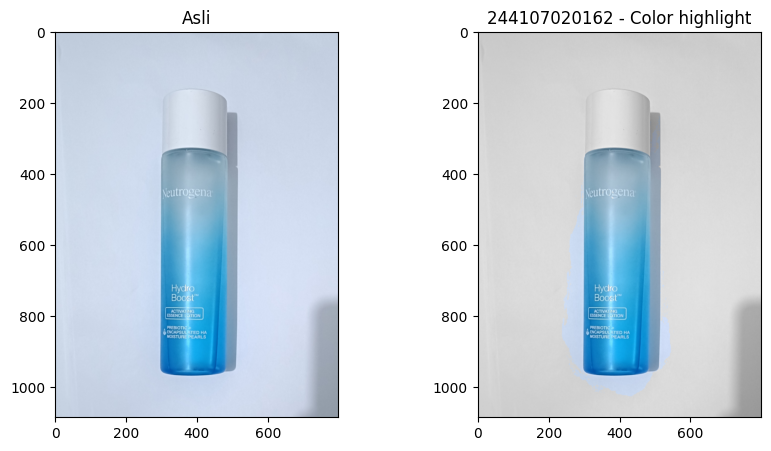

In [137]:
original = resize_image(cv.imread(BASE + '/OBJ1.jpg'))
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

lower_blue = np.array([85, 40, 40])
upper_blue = np.array([135, 255, 255])
mask = cv.inRange(hsv, lower_blue, upper_blue)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

result = np.where(mask[:, :, None] > 0, original, gray_bgr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1);
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB));
plt.title('Asli')

plt.subplot(1, 2, 2);
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB));
plt.title(NIM + ' - Color highlight')

plt.show()

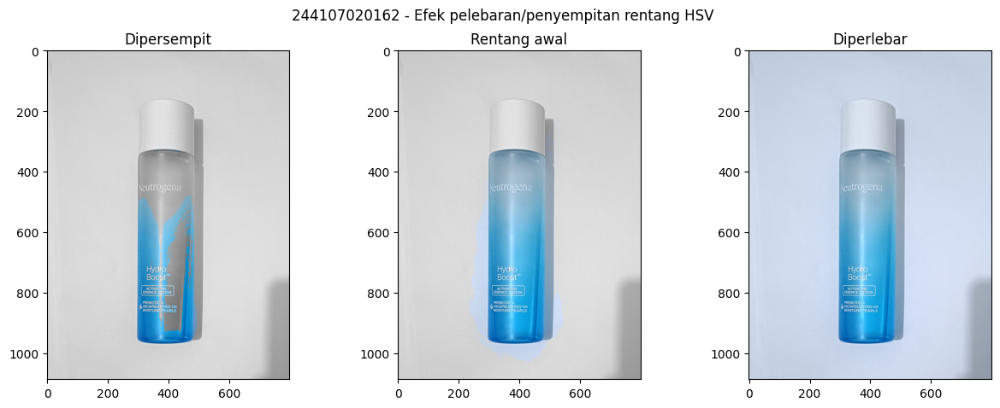

In [138]:
# EXPERIMEN RENTANG HSV
original = resize_image(cv.imread(BASE + '/OBJ1.jpg'))
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# 1. Rentang Dipersempit
lower_narrow = np.array([100, 100, 100])
upper_narrow = np.array([125, 255, 255])
mask_narrow = cv.inRange(hsv, lower_narrow, upper_narrow)
result_narrow = np.where(mask_narrow[:, :, None] > 0, original, gray_bgr)

# 2. Rentang Pas
lower_pas = np.array([85, 40, 40])
upper_pas = np.array([135, 255, 255])
mask_pas = cv.inRange(hsv, lower_pas, upper_pas)
result_pas = np.where(mask_pas[:, :, None] > 0, original, gray_bgr)

# 3. Rentang Diperlebar
lower_wide = np.array([75, 20, 20])
upper_wide = np.array([150, 255, 255])
mask_wide = cv.inRange(hsv, lower_wide, upper_wide)
result_wide = np.where(mask_wide[:, :, None] > 0, original, gray_bgr)

# Visualisasi 3 Rentang
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(result_narrow, cv.COLOR_BGR2RGB))
plt.title('Dipersempit')
plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(result_pas, cv.COLOR_BGR2RGB))
plt.title('Rentang awal')
plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(result_wide, cv.COLOR_BGR2RGB))
plt.title('Diperlebar')

plt.suptitle(NIM + ' - Efek pelebaran/penyempitan rentang HSV')
plt.show()

**Tugas 6 - Gamma Correction pada Citra Pribadi**

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: gamma
Error, not a number
244107020162 - Gamma Correction (gamma = 0.4 )


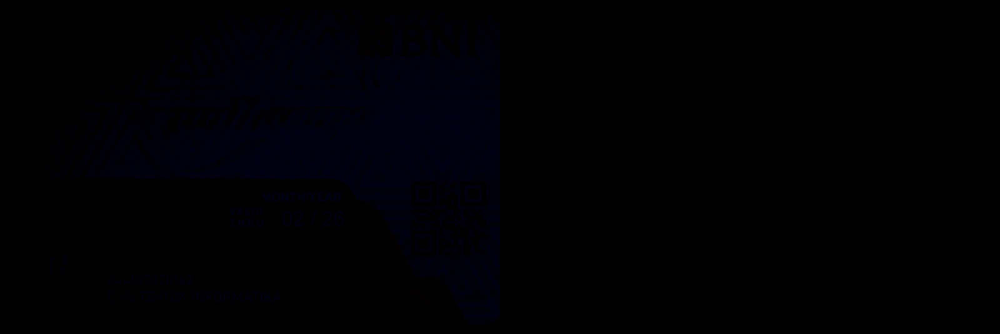

In [139]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = PARAM['gamma']

original = resize_image(cv.imread(BASE + '/KTM1a.jpg'))
gamma_image = 255 * (original.astype(np.float64) / 255) ** (1 / gamma)
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((original, gamma_image))
print(NIM, '- Gamma Correction (gamma =', gamma, ')')
cv2_imshow(final_frame)

244107020162 - gamma = 0.4


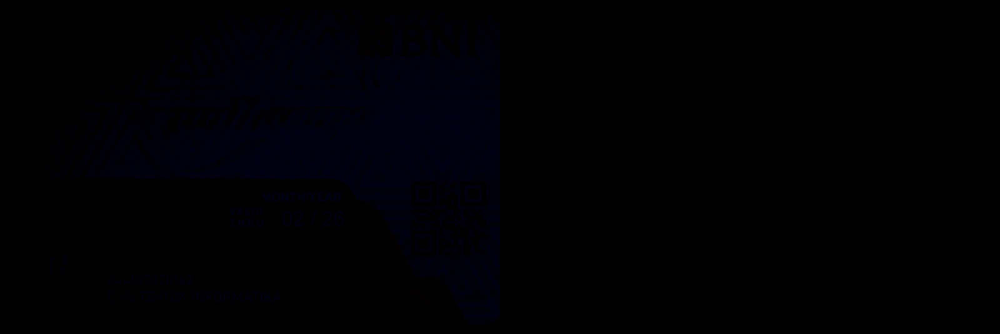

244107020162 - gamma = 1


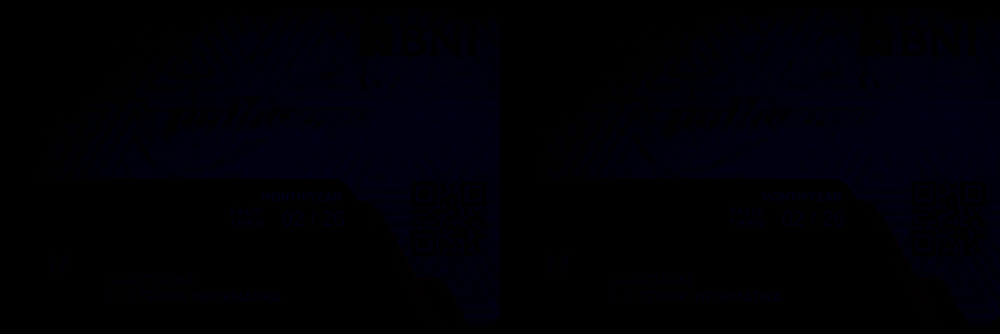

244107020162 - gamma = 1.6


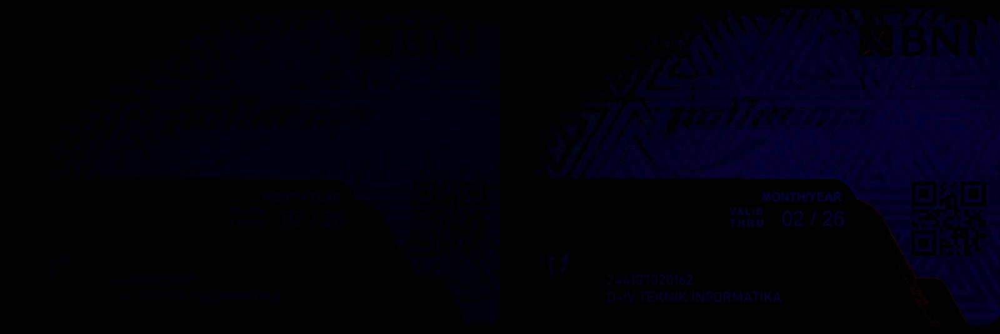

244107020162 - gamma = 2.2


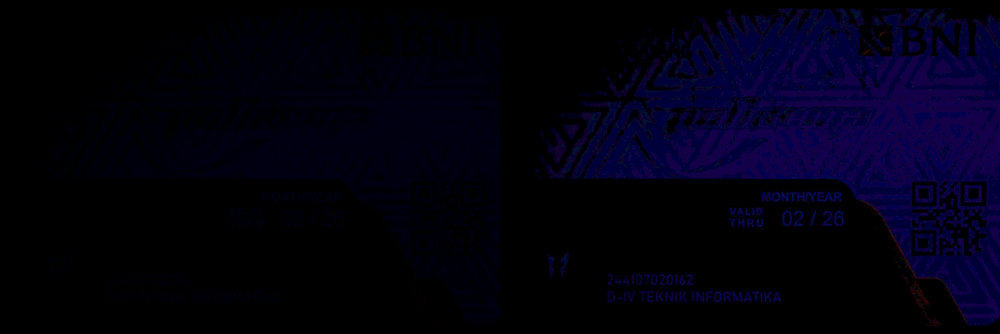

244107020162 - gamma = 2.8


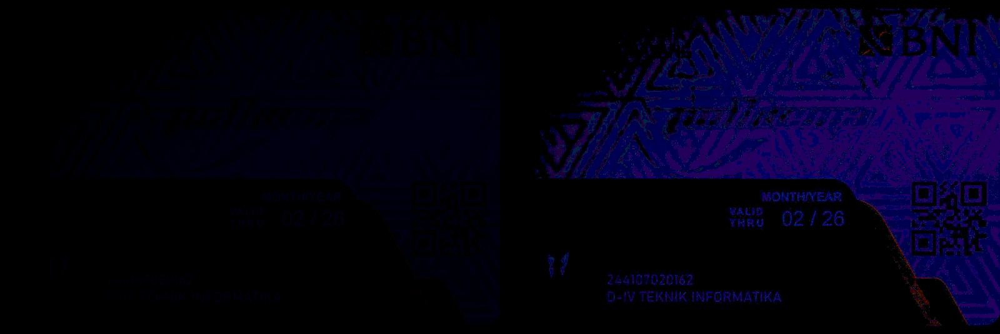

244107020162 - gamma = 3.4


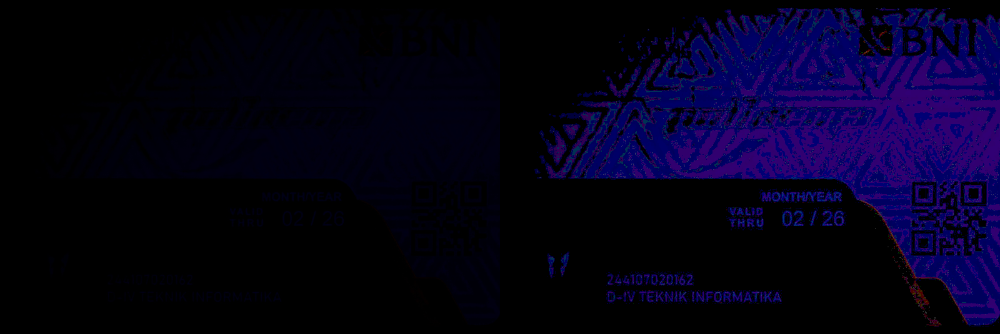

In [140]:
# coba beberapa nilai gamma sekaligus
gamma_list = [PARAM['gamma'], 1, 1.6,2.2, 2.8, 3.4]

for g in gamma_list:
    hasil = 255 * (original.astype(np.float64) / 255) ** (1 / g)
    hasil = np.clip(hasil, 0, 255).astype(np.uint8)
    final_frame = cv.hconcat((original, hasil))
    print(NIM, '- gamma =', g)
    cv2_imshow(final_frame)

Gamma terbaik pilihan saya adalah gamma 2,2. Karena saya bisa melihat NIM saya dengan jelas dan kualitasnya tidak begitu terpecah, meskipun dari tiap percobaan, Nama saya tidak dapat terlihat.

Alasan kenapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama, adalah karena perbedaan intensitas kegelapan serta cahaya yang ditangkap dari objek yang difoto. Oleh karena itu, hasil nilai terbaiknya selalu berbeda.

**Tugas 7 - Simulasi Image Depth pada Citra Pribadi**

244107020162 - 1 bit ( 2 warna )


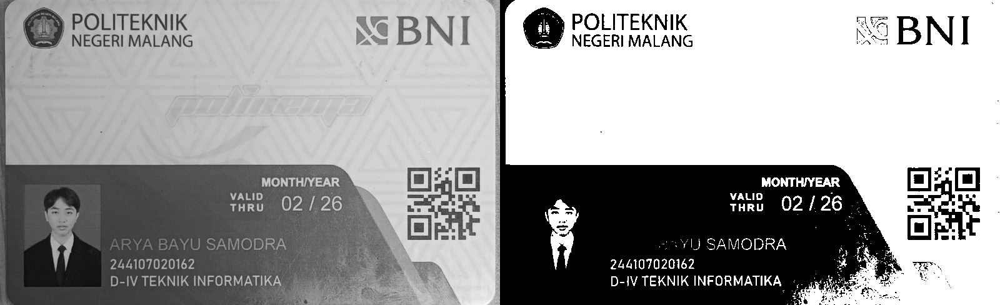

244107020162 - 2 bit ( 4 warna )


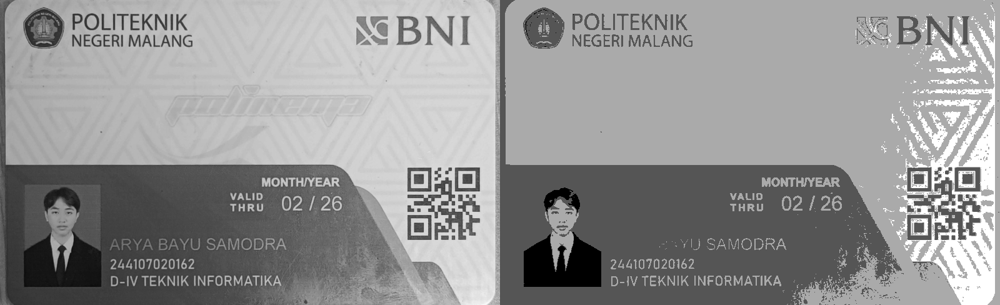

244107020162 - 3 bit ( 8 warna )


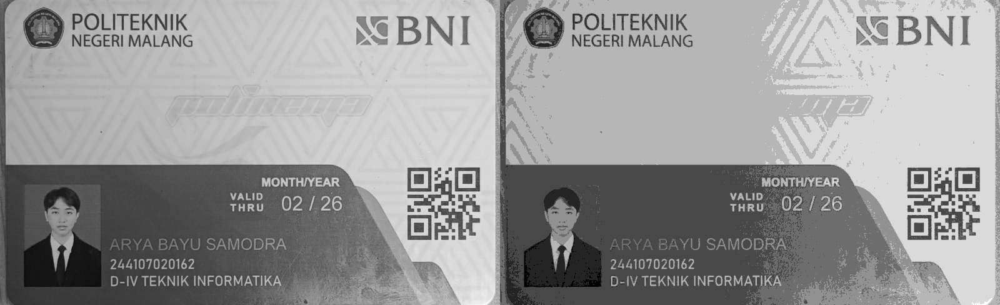

244107020162 - 4 bit ( 16 warna )


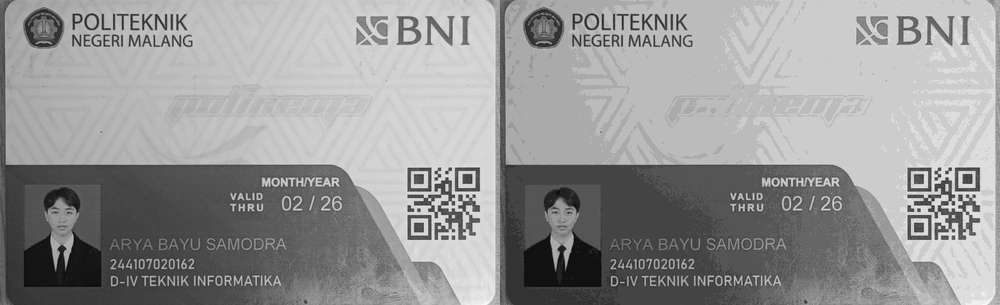

244107020162 - 5 bit ( 32 warna )


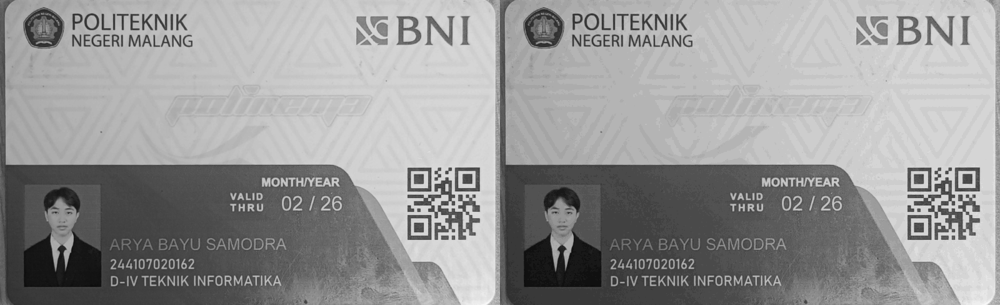

244107020162 - 6 bit ( 64 warna )


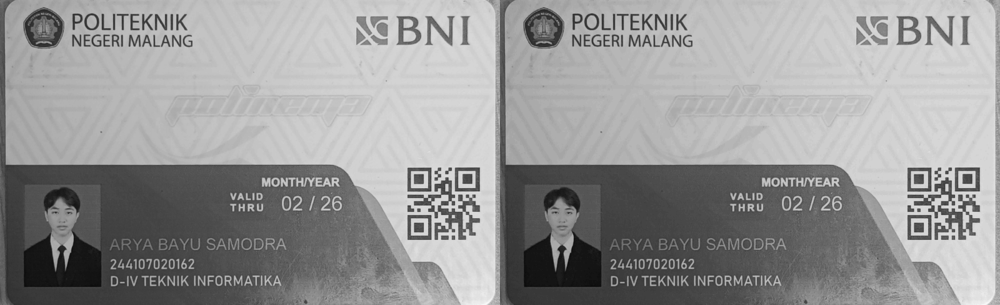

244107020162 - 7 bit ( 128 warna )


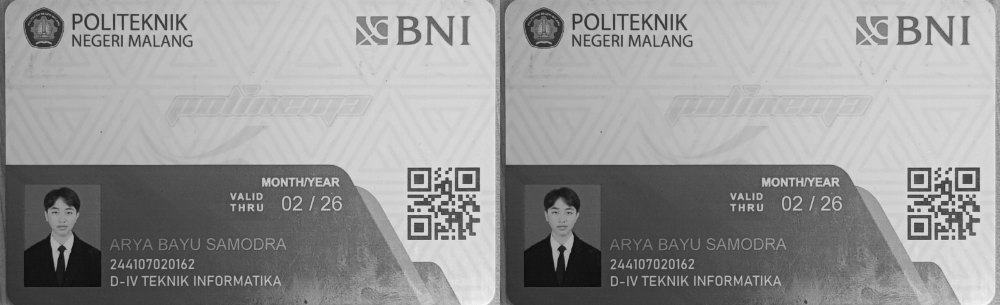

In [141]:
original = resize_image(cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE))

for bit_depth in range(1, 8):
    level = 255 / (pow(2, bit_depth) - 1)
    depth_image = np.round(original / level) * level
    depth_image = depth_image.astype(np.uint8)

    final_frame = cv.hconcat((original, depth_image))
    print(NIM, '-', bit_depth, 'bit (', pow(2, bit_depth), 'warna )')
    cv2_imshow(final_frame)

244107020162 - bit depth dari NIM = 2


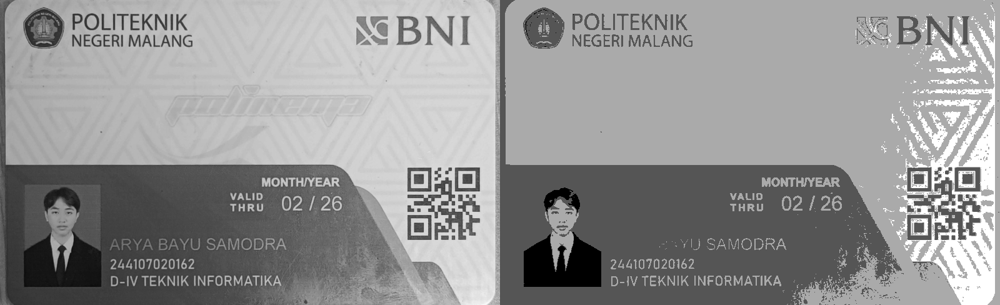

In [142]:
# kuantisasi pada bit depth hasil hitung NIM
bit_depth = PARAM['bit']
level = 255 / (pow(2, bit_depth) - 1)
depth_image_nim = np.round(original / level) * level
depth_image_nim = depth_image_nim.astype(np.uint8)

final_frame = cv.hconcat((original, depth_image_nim))
print(NIM, "- bit depth dari NIM =", bit_depth)
cv2_imshow(final_frame)


Pada kedalaman 3-bit nama dan NIM pada kartu saya masih terbaca. Namun dibawah 3-bit, nama depan saya mulai tidak terlihat.

**Tugas 8 - Average Denoising**

In [143]:
GALAXY_PATH = '/content/drive/MyDrive/PCVK/Images/galaxy.jpg'
NOISES_DIR  = '/content/drive/MyDrive/PCVK/Images/noises'

original = resize_image(cv.imread(GALAXY_PATH))

cv_img = []
for img in glob.glob(NOISES_DIR + '/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

print('Jumlah citra noise terbaca:', len(cv_img))

Jumlah citra noise terbaca: 100


In [144]:
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

244107020162 - Average 10 citra | PSNR = 19.723 dB


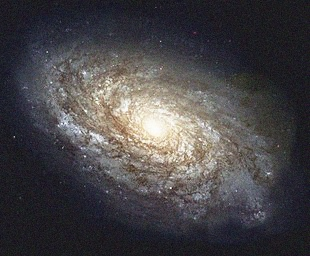

244107020162 - Average 20 citra | PSNR = 19.831 dB


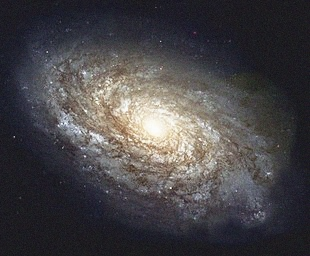

244107020162 - Average 40 citra | PSNR = 19.888 dB


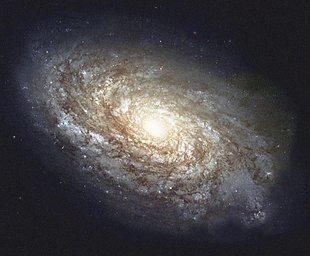

244107020162 - Average 80 citra | PSNR = 19.915 dB


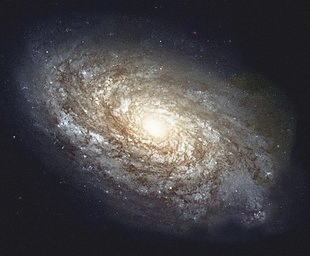

244107020162 - Average 100 citra | PSNR = 19.922 dB


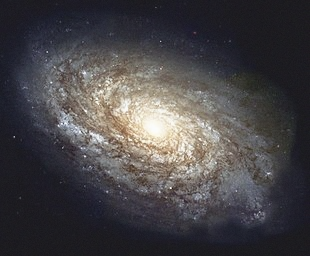

In [145]:
jumlah_list = [10, 20, 40, 80, 100]

for n in jumlah_list:
    stack = np.stack([im.astype(np.float64) for im in cv_img[:n]], axis=0)
    denoised = np.mean(stack, axis=0).astype(np.uint8)
    psnr_val = PSNR(original, denoised)

    print(NIM, '- Average', n, 'citra | PSNR =', round(psnr_val, 3), 'dB')
    cv2_imshow(denoised)


Peningkatan PSNR tidak selalu signifikan.

Peningkatan PSNR mulai tidak signifikan pada kisaran 20 hingga 40 citra, karena disitu terlihat mulai melambat dengan peningkatan hanya 0,057dB. Yang dimana peningkatan sebelumnya adalah 0,108dB.

Kesimpulan yang bisa diambil dari percobaan ini yaitu metode ini sangat efektif untuk mengurangi noise acak, namun peningkatan nilai PSNR terhadap jumlah citra bersifat logaritmik. Oleh karena itu, penggunaan 20–40 citra merupakan titik batas paling efisien yang menyeimbangkan antara kualitas hasil perbaikan citra dengan beban komputasi dan memori.

**Tugas 9 - Image Masking untuk Penyamaran Data Pribadi**

Ukuran citra KTM1d.jpg: 800 x 510
244107020162 - Image Masking (AND)


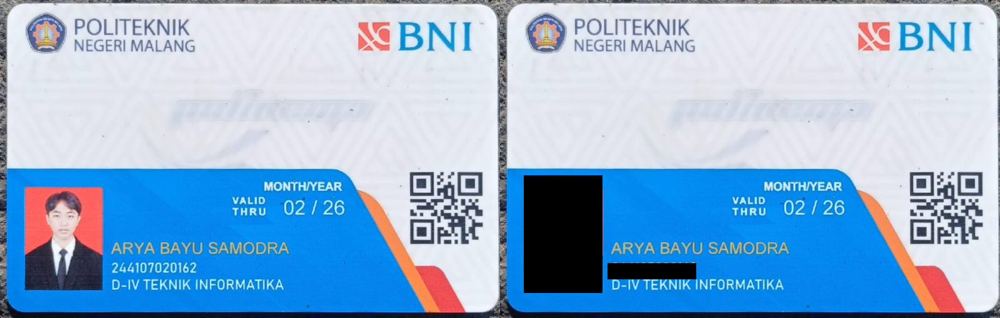

Koordinat kotak wajah (x1,y1,x2,y2): (38, 281, 163, 469)
Koordinat kotak NIM   (x1,y1,x2,y2): (172, 422, 313, 447)


In [147]:
original = resize_image(cv.imread(BASE + '/KTM1d.jpg'))
h, w = original.shape[:2]
print('Ukuran citra KTM1d.jpg:', w, 'x', h)

kotak_wajah = (38, 281, 163, 469)
kotak_nim   = (172, 422, 313, 447)

mask = np.ones((h, w), dtype=np.uint8) * 255
cv.rectangle(mask, kotak_wajah[:2], kotak_wajah[2:], 0, -1)
cv.rectangle(mask, kotak_nim[:2],   kotak_nim[2:],   0, -1)

mask_3ch = cv.merge([mask, mask, mask])
masked_image = cv.bitwise_and(original, mask_3ch)

final_frame = cv.hconcat((original, masked_image))
print(NIM, '- Image Masking (AND)')
cv2_imshow(final_frame)

print('Koordinat kotak wajah (x1,y1,x2,y2):', kotak_wajah)
print('Koordinat kotak NIM   (x1,y1,x2,y2):', kotak_nim)


244107020162 - Operator NOT


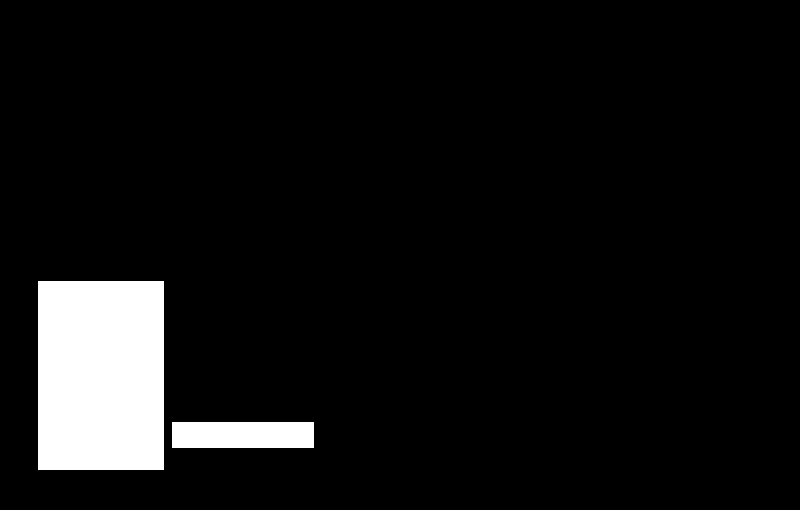

244107020162 - Operator OR


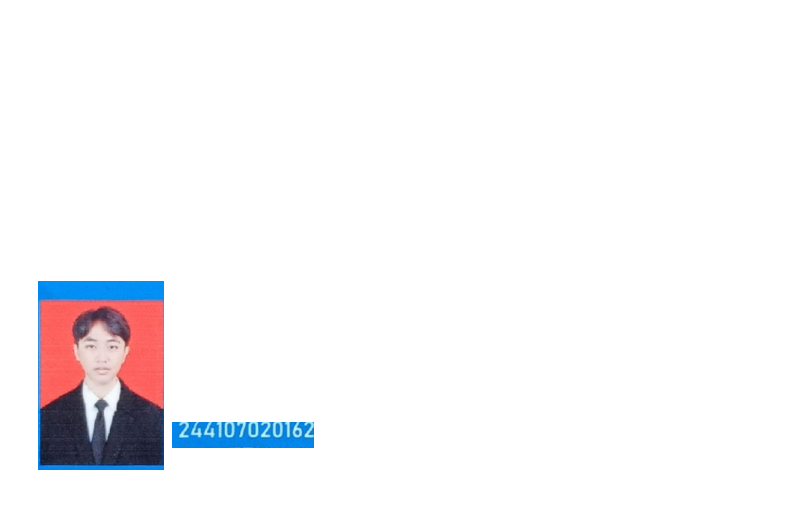

244107020162 - Operator AND


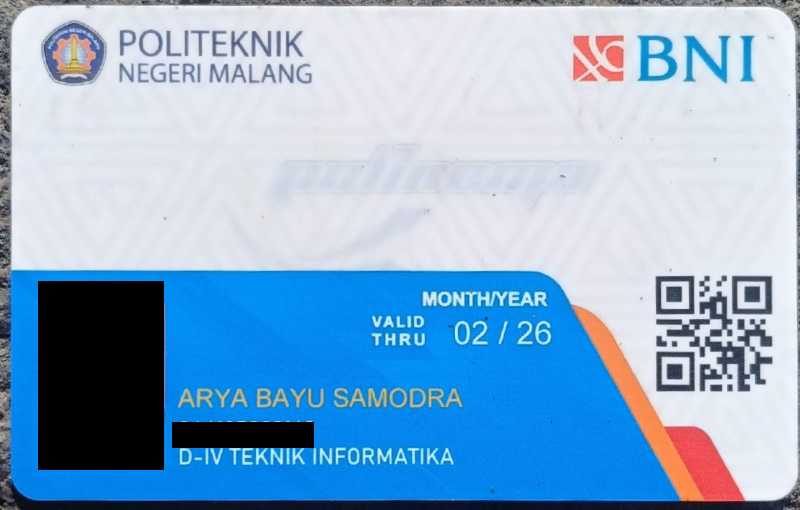

244107020162 - Operator NAND


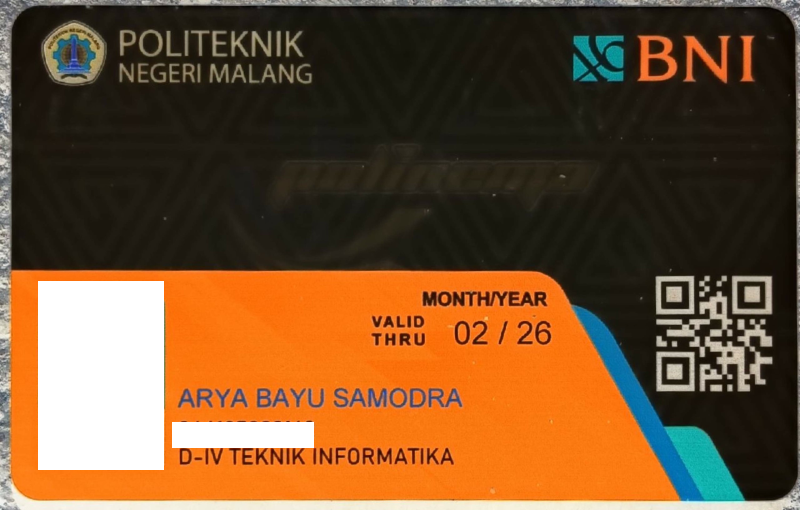

244107020162 - Operator XOR


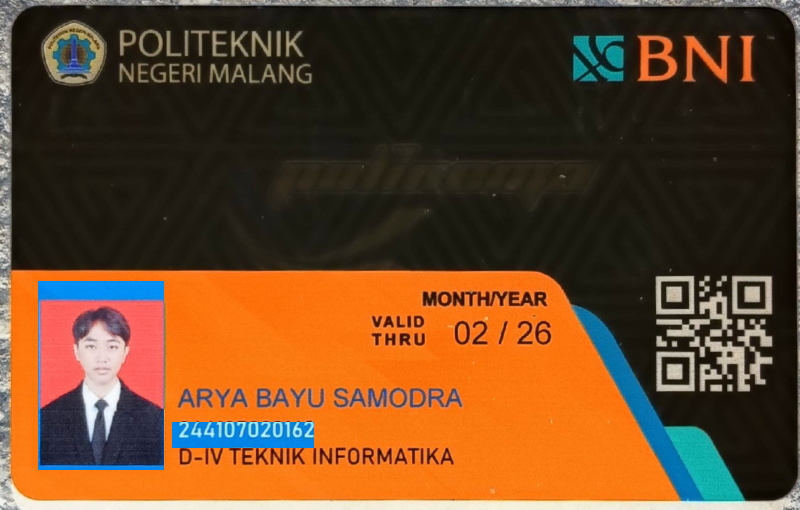

In [148]:
# eksperimen operator logika lain pada mask yang sama
hasil_not  = cv.bitwise_not(mask_3ch)
hasil_or   = cv.bitwise_or(original, mask_3ch)
hasil_and  = cv.bitwise_and(original, mask_3ch)
hasil_nand = cv.bitwise_not(cv.bitwise_and(original, mask_3ch))
hasil_xor  = cv.bitwise_xor(original, mask_3ch)

for nama, hasil in [('NOT', hasil_not), ('OR', hasil_or), ('AND', hasil_and),
                     ('NAND', hasil_nand), ('XOR', hasil_xor)]:
    print(NIM, '- Operator', nama)
    cv2_imshow(hasil)

**Hasil Analisa:**

AND adalah operator yang benar untuk masking (area mask 0 menghitamkan
pixel citra, area mask 255 mempertahankan pixel asli). NOT membalik mask sehingga area
yang tadinya tersembunyi jadi terlihat. OR dengan mask yang mayoritas putih membuat hampir
seluruh citra jadi putih. NAND adalah kebalikan AND. XOR menghasilkan efek negatif parsial
pada area mask putih.

**Tugas 10 - Foto Malam Hari**

244107020162 - Perbaikan Foto Malam Hari (gamma=0.45, contrast=1.2)


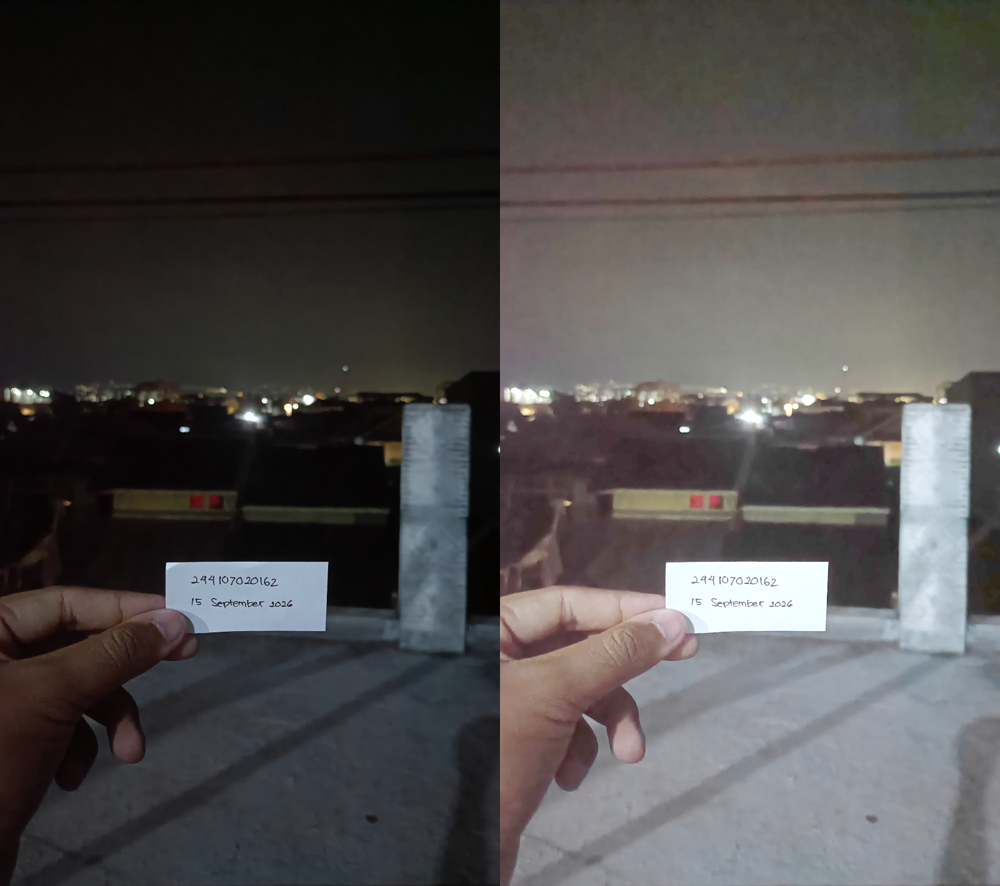

In [149]:
original = resize_image(cv.imread(BASE + '/NIGHT1.jpg'))

gamma_malam = 0.45
contrast_malam = 1.2

step1 = 255.0 * ((original.astype(np.float64) / 255.0) ** gamma_malam)
step1 = np.clip(step1, 0, 255).astype(np.uint8)

step2 = np.clip(contrast_malam * step1.astype(np.float64), 0, 255).astype(np.uint8)

final_frame = cv.hconcat((original, step2))
print(NIM, f'- Perbaikan Foto Malam Hari (gamma={gamma_malam}, contrast={contrast_malam})')
cv2_imshow(final_frame)

**Metode yang Dipilih**:
Kombinasi Gamma Correction dan Contrast Adjustment.


**Alasan Pemilihan**:
Karena citra malam hari yang sama ambil memiliki rentang pencahayaan yang sangat timpang antara latar belakang dan lantai sangat gelap, sedangkan tulisan di kertas dan lampu di kejauhan sudah terang.
